In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = '/content/drive/MyDrive/UAS_Data_Mining_Berita'

os.listdir(project_path)

['dataset', 'notebook', 'model', 'app']

In [ ]:
dataset_path = '/content/drive/MyDrive/UAS_Data_Mining_Berita/dataset'

os.listdir(dataset_path)

['final_merge_dataset.csv']

In [ ]:
!pip install Sastrawi joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 87.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import joblib
import os

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
file_path = '/content/drive/MyDrive/UAS_Data_Mining_Berita/dataset/indonesia_news_dataset.csv'

df = pd.read_csv(file_path)

df.head()

,Judul,Waktu,Link,Content,tag1,tag2,tag3,tag4,tag5,source
0,"Viral Isu PHK Buruh Gudang Garam, Said Iqbal: ...",6 September 2025,https://nasional.kompas.com/read/2025/09/06/14...,"JAKARTA, KOMPAS.com – Presiden Konfederasi Se...",Said Iqbal,industri rokok,PT Gudang Garam,PHK massal,phk massal 2025 terbaru,kompas
1,"Gempa M 5,3 Guncang Pulau Doi Maluku Utara","Senin, 12 Agu 2024 21:58 WIB",https://news.detik.com/berita/d-7486691/gempa-...,"Gempa bumi berkekuatan magnitudo (M) 5,3 mengg...",pulau doi,gempa,NaN,NaN,NaN,detik
2,"Toko Emas Palsu di Riau Dibongkar Polisi, Perh...","Rabu, 30 Jul 2025 22:22 WIB",https://news.detik.com/melindungi-tuah-marwah/...,Satreskrim Polres Bengkalis membongkar praktik...,pemalsuan emas,emas palsu,polres bengkalis,polda riau,melindungi tuah marwah,detik
3,Minyakita Tak Sesuai Ukuran juga Ditemukan di ...,"Senin, 10 Mar 2025 23:15 WIB",https://news.detik.com/berita/d-7816829/minyak...,Polisi mendatangi salah satu gudang Minyakita ...,minyakita,kudus,NaN,NaN,NaN,detik
4,"Pimpin LDP, Sanae Takaichi Calon Kuat PM Perem...",4 Oktober 2025 | 14.00 WIB,https://www.tempo.co/internasional/pimpin-ldp-...,"Baca berita dengan sedikit iklan, klik di sin...",jepang,perdana-menteri,sanae-takaichi,perempuan,ldp,tempo


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80472 entries, 0 to 80471
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Judul    80472 non-null  object
 1   Waktu    80472 non-null  object
 2   Link     80472 non-null  object
 3   Content  80463 non-null  object
 4   tag1     78023 non-null  object
 5   tag2     77612 non-null  object
 6   tag3     71602 non-null  object
 7   tag4     56856 non-null  object
 8   tag5     35633 non-null  object
 9   source   80472 non-null  object
dtypes: object(10)
memory usage: 6.1+ MB


In [ ]:
df.columns

Index(['Judul', 'Waktu', 'Link', 'Content', 'tag1', 'tag2', 'tag3', 'tag4',
       'tag5', 'source'],
      dtype='object')

In [ ]:
# Mengambil kolom yang dibutuhkan
df = df[['Judul', 'Content', 'tag1', 'source', 'Waktu', 'Link']]

# Menghapus data kosong pada kolom penting
df = df.dropna(subset=['Judul', 'Content', 'tag1'])

# Menggabungkan judul dan isi berita menjadi satu kolom teks
df['text'] = df['Judul'].astype(str) + ' ' + df['Content'].astype(str)

# Menggunakan tag1 sebagai kategori/topik
df['category'] = df['tag1'].astype(str)

# Mengambil hanya kolom yang dibutuhkan untuk model
df = df[['text', 'category', 'source', 'Waktu', 'Link']]

# Menampilkan 5 data pertama
df.head()

,text,category,source,Waktu,Link
0,"Viral Isu PHK Buruh Gudang Garam, Said Iqbal: ...",Said Iqbal,kompas,6 September 2025,https://nasional.kompas.com/read/2025/09/06/14...
1,"Gempa M 5,3 Guncang Pulau Doi Maluku Utara Gem...",pulau doi,detik,"Senin, 12 Agu 2024 21:58 WIB",https://news.detik.com/berita/d-7486691/gempa-...
2,"Toko Emas Palsu di Riau Dibongkar Polisi, Perh...",pemalsuan emas,detik,"Rabu, 30 Jul 2025 22:22 WIB",https://news.detik.com/melindungi-tuah-marwah/...
3,Minyakita Tak Sesuai Ukuran juga Ditemukan di ...,minyakita,detik,"Senin, 10 Mar 2025 23:15 WIB",https://news.detik.com/berita/d-7816829/minyak...
4,"Pimpin LDP, Sanae Takaichi Calon Kuat PM Perem...",jepang,tempo,4 Oktober 2025 | 14.00 WIB,https://www.tempo.co/internasional/pimpin-ldp-...


In [ ]:
# Membuat kategori menjadi huruf kecil dan menghapus spasi berlebih
df['category'] = df['category'].str.lower().str.strip()

# Melihat jumlah data tiap kategori
df['category'].value_counts().head(30)

,count
category,
kpk,1244
prabowo,1176
prabowo subianto,996
jakarta,911
pramono anung,659
ridwan kamil,516
jokowi,494
israel,358
kebakaran,339


In [ ]:
# Mengambil 10 kategori/topik paling banyak
top_categories = df['category'].value_counts().head(10).index

# Filter dataset hanya untuk 10 kategori tersebut
df_filtered = df[df['category'].isin(top_categories)]

# Cek jumlah data setelah difilter
df_filtered['category'].value_counts()

,count
category,
kpk,1244
prabowo,1176
prabowo subianto,996
jakarta,911
pramono anung,659
ridwan kamil,516
jokowi,494
israel,358
kebakaran,339


In [ ]:
# Mengambil kolom final untuk pemodelan
df_model = df_filtered[['text', 'category']].copy()

# Menghapus data duplikat
df_model = df_model.drop_duplicates()

# Menampilkan ukuran dataset final
df_model.shape

(5567, 2)

In [ ]:
df_model.head()

,text,category
5,Gubernur Banten Terpilih Andra Soni Temui Pres...,prabowo subianto
19,Prabowo Minta Legislator Gerindra Jaga Ucapan ...,prabowo
21,"Pipa Besi Jatuh dari Atas Tol Penjaringan, Kio...",jakarta
29,KPK Tahan 4 Tersangka Kasus Dana Hibah Jatim B...,kpk
34,Anggota DPRD DKI Kenneth Usulkan Calon Petugas...,pramono anung


In [ ]:
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df_model['clean_text'] = df_model['text'].apply(clean_text)

df_model.head()

,text,category,clean_text
5,Gubernur Banten Terpilih Andra Soni Temui Pres...,prabowo subianto,gubernur banten terpilih andra soni temui pres...
19,Prabowo Minta Legislator Gerindra Jaga Ucapan ...,prabowo,prabowo minta legislator gerindra jaga ucapan ...
21,"Pipa Besi Jatuh dari Atas Tol Penjaringan, Kio...",jakarta,pipa besi jatuh dari atas tol penjaringan kios...
29,KPK Tahan 4 Tersangka Kasus Dana Hibah Jatim B...,kpk,kpk tahan tersangka kasus dana hibah jatim bac...
34,Anggota DPRD DKI Kenneth Usulkan Calon Petugas...,pramono anung,anggota dprd dki kenneth usulkan calon petugas...


In [ ]:
jumlah_data = min(5000, len(df_model))

df_sample = df_model.sample(jumlah_data, random_state=42)

df_sample.shape

(5000, 3)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X = df_sample['clean_text']
y = df_sample['category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model:", accuracy)
print(classification_report(y_test, y_pred))

Akurasi Model: 0.767
                  precision    recall  f1-score   support

      info-tempo       0.98      0.81      0.89        53
          israel       1.00      0.80      0.89        40
         jakarta       0.76      0.92      0.83       162
          jokowi       0.91      0.42      0.57        72
       kebakaran       1.00      0.45      0.62        31
             kpk       0.93      0.98      0.95       158
         prabowo       0.56      0.96      0.71       204
prabowo subianto       0.78      0.18      0.29       117
   pramono anung       0.89      0.72      0.80        90
    ridwan kamil       0.94      0.86      0.90        73

        accuracy                           0.77      1000
       macro avg       0.87      0.71      0.75      1000
    weighted avg       0.81      0.77      0.74      1000



In [ ]:
teks_baru = "Pemerintah Provinsi Jawa Timur memperluas layanan transportasi publik melalui program Trans Jatim."

teks_baru_clean = clean_text(teks_baru)

teks_baru_tfidf = tfidf.transform([teks_baru_clean])

hasil = model.predict(teks_baru_tfidf)

print("Prediksi kategori:", hasil[0])

Prediksi kategori: info-tempo


In [34]:
import joblib
import os

model_path = '/content/drive/MyDrive/UAS_Data_Mining_Berita/model'

# Pastikan folder model ada
os.makedirs(model_path, exist_ok=True)

# Simpan model dan TF-IDF
joblib.dump(model, model_path + '/model_berita.pkl')
joblib.dump(tfidf, model_path + '/vectorizer_tfidf.pkl')

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [35]:
os.listdir(model_path)

['model_berita.pkl', 'vectorizer_tfidf.pkl']

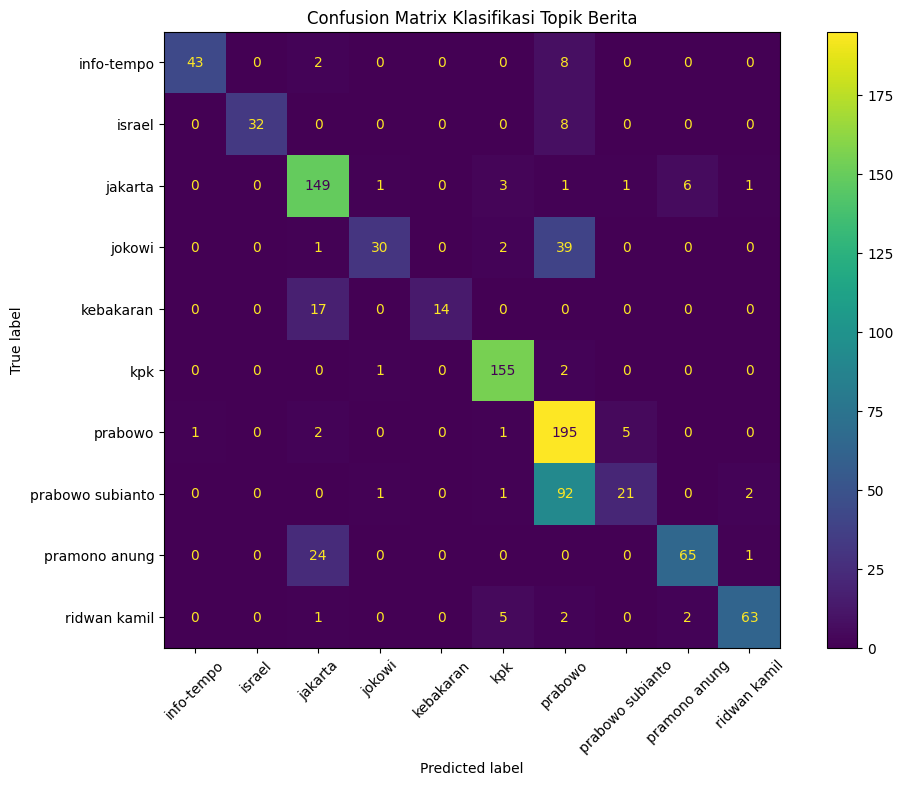

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(12, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix Klasifikasi Topik Berita")
plt.show()

In [37]:
hasil_prediksi = pd.DataFrame({
    'Teks_Berita': X_test.values,
    'Kategori_Asli': y_test.values,
    'Kategori_Prediksi': y_pred
})

hasil_path = '/content/drive/MyDrive/UAS_Data_Mining_Berita/model/hasil_prediksi.csv'

hasil_prediksi.to_csv(hasil_path, index=False)

print("Hasil prediksi berhasil disimpan.")

Hasil prediksi berhasil disimpan.


In [38]:
os.listdir('/content/drive/MyDrive/UAS_Data_Mining_Berita/model')

['model_berita.pkl', 'vectorizer_tfidf.pkl', 'hasil_prediksi.csv']

In [42]:
app_code = """
import streamlit as st
import joblib
import re
import string

# Load model dan vectorizer
model = joblib.load('model_berita.pkl')
tfidf = joblib.load('vectorizer_tfidf.pkl')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\\S+|www\\S+', ' ', text)
    text = re.sub(r'\\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

st.set_page_config(
    page_title='Klasifikasi Topik Berita Indonesia',
    page_icon='📰',
    layout='centered'
)

st.title('📰 Klasifikasi Topik Berita Indonesia')
st.write(
    'Aplikasi ini menggunakan metode TF-IDF dan algoritma Naive Bayes '
    'untuk memprediksi topik berita berdasarkan teks yang dimasukkan.'
)

st.markdown('---')

input_text = st.text_area(
    'Masukkan judul atau isi berita:',
    height=200,
    placeholder='Contoh: Pemerintah Provinsi Jawa Timur memperluas layanan transportasi publik melalui program Trans Jatim.'
)

if st.button('Prediksi Topik Berita'):
    if input_text.strip() == '':
        st.warning('Silakan masukkan teks berita terlebih dahulu.')
    else:
        clean = clean_text(input_text)
        vector = tfidf.transform([clean])
        prediction = model.predict(vector)[0]

        st.success(f'Prediksi Topik Berita: {prediction}')

        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(vector)[0]
            classes = model.classes_

            result = sorted(
                zip(classes, proba),
                key=lambda x: x[1],
                reverse=True
            )

            st.subheader('Probabilitas Prediksi')
            for label, score in result[:5]:
                st.write(f'{label}: {score:.2%}')

st.markdown('---')
st.caption('UAS Data Mining - Klasifikasi Topik Berita Indonesia Tahun 2024-2025')
"""

In [43]:
app_folder = '/content/drive/MyDrive/UAS_Data_Mining_Berita/app'
os.makedirs(app_folder, exist_ok=True)

app_path = app_folder + '/app.py'

with open(app_path, 'w') as f:
    f.write(app_code)

print("File app.py berhasil dibuat.")

File app.py berhasil dibuat.


In [44]:
os.listdir(app_folder)

['app.py']

In [45]:
import shutil

shutil.copy(
    '/content/drive/MyDrive/UAS_Data_Mining_Berita/model/model_berita.pkl',
    '/content/drive/MyDrive/UAS_Data_Mining_Berita/app/model_berita.pkl'
)

shutil.copy(
    '/content/drive/MyDrive/UAS_Data_Mining_Berita/model/vectorizer_tfidf.pkl',
    '/content/drive/MyDrive/UAS_Data_Mining_Berita/app/vectorizer_tfidf.pkl'
)

print("Model berhasil disalin ke folder app.")

Model berhasil disalin ke folder app.


In [46]:
os.listdir('/content/drive/MyDrive/UAS_Data_Mining_Berita/app')

['app.py', 'model_berita.pkl', 'vectorizer_tfidf.pkl']

In [47]:
requirements_code = """streamlit
pandas
numpy
scikit-learn
joblib
"""

requirements_path = '/content/drive/MyDrive/UAS_Data_Mining_Berita/app/requirements.txt'

with open(requirements_path, 'w') as f:
    f.write(requirements_code)

print("requirements.txt berhasil dibuat.")

requirements.txt berhasil dibuat.


In [48]:
os.listdir('/content/drive/MyDrive/UAS_Data_Mining_Berita/app')

['app.py', 'model_berita.pkl', 'vectorizer_tfidf.pkl', 'requirements.txt']

In [53]:
readme_code = """
# Klasifikasi Topik Berita Indonesia Tahun 2024-2025

Project ini dibuat untuk memenuhi tugas Ujian Akhir Semester mata kuliah Data Mining.

## Judul Project

Klasifikasi Topik Berita Indonesia Tahun 2024-2025 Menggunakan TF-IDF dan Algoritma Naive Bayes Berdasarkan Tag Berita.

## Dataset

Dataset yang digunakan adalah Indonesia News Dataset yang berisi data berita Indonesia dari beberapa media, seperti Kompas, Detik, dan Tempo.

Kolom yang digunakan dalam project ini:

- Judul
- Content
- tag1
- source
- Waktu
- Link

Pada penelitian ini, kolom Judul dan Content digabungkan sebagai teks berita, sedangkan tag1 digunakan sebagai label/topik berita.

## Metode

Tahapan penelitian:

1. Pengumpulan dataset
2. Seleksi atribut
3. Preprocessing teks
4. Pembobotan kata menggunakan TF-IDF
5. Pembagian data training dan testing
6. Klasifikasi menggunakan algoritma Multinomial Naive Bayes
7. Evaluasi model
8. Implementasi aplikasi menggunakan Streamlit

## Algoritma

Algoritma yang digunakan:

- TF-IDF Vectorizer
- Multinomial Naive Bayes

## Cara Menjalankan Aplikasi

Install library:

```bash
pip install -r requirements.txt

SyntaxError: incomplete input (2083520839.py, line 1)

In [54]:
%%writefile /content/drive/MyDrive/UAS_Data_Mining_Berita/app/README.md
# Klasifikasi Topik Berita Indonesia Tahun 2024-2025

Project ini dibuat untuk memenuhi tugas Ujian Akhir Semester mata kuliah Data Mining.

## Judul Project

Klasifikasi Topik Berita Indonesia Tahun 2024-2025 Menggunakan TF-IDF dan Algoritma Naive Bayes Berdasarkan Tag Berita.

## Dataset

Dataset yang digunakan adalah Indonesia News Dataset yang berisi data berita Indonesia dari beberapa media, seperti Kompas, Detik, dan Tempo.

Kolom yang digunakan dalam project ini:

- Judul
- Content
- tag1
- source
- Waktu
- Link

Pada penelitian ini, kolom Judul dan Content digabungkan sebagai teks berita, sedangkan tag1 digunakan sebagai label/topik berita.

## Metode

Tahapan penelitian:

1. Pengumpulan dataset
2. Seleksi atribut
3. Preprocessing teks
4. Pembobotan kata menggunakan TF-IDF
5. Pembagian data training dan testing
6. Klasifikasi menggunakan algoritma Multinomial Naive Bayes
7. Evaluasi model
8. Implementasi aplikasi menggunakan Streamlit

## Algoritma

Algoritma yang digunakan:

- TF-IDF Vectorizer
- Multinomial Naive Bayes

## Cara Menjalankan Aplikasi

Install library:

pip install -r requirements.txt

Jalankan aplikasi:

streamlit run app.py

## Output Aplikasi

Pengguna memasukkan teks berita, kemudian aplikasi akan menampilkan prediksi topik berita berdasarkan model yang sudah dilatih.

Writing /content/drive/MyDrive/UAS_Data_Mining_Berita/app/README.md


In [56]:
import os

os.listdir('/content/drive/MyDrive/UAS_Data_Mining_Berita/app')

['app.py',
 'model_berita.pkl',
 'vectorizer_tfidf.pkl',
 'requirements.txt',
 'README.md']

In [57]:
!pip install streamlit pyngrok

In [58]:
%cd /content/drive/MyDrive/UAS_Data_Mining_Berita/app

/content/drive/MyDrive/UAS_Data_Mining_Berita/app


In [59]:
!streamlit run app.py



2026-06-10 02:21:54.853 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.108.41:8501

  Stopping...
  Stopping...


In [60]:
%cd /content/drive/MyDrive/UAS_Data_Mining_Berita/app

!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > streamlit.log 2>&1 &

/content/drive/MyDrive/UAS_Data_Mining_Berita/app


In [62]:
from google.colab import output

print(output.eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-usw3b2-2y5azyp9onae-b.us-west3-2.prod.colab.dev
